# Optuna

Optuna is a library that is used for hyperparameter tuning

Instead of trying out parameters values randomly as Random search cv or trying every parameter value as in Grid search cv it analayses by which parameters our accuracy is improving and then get's us the best parameters.

It also provide an option to tune best model among various models

## Key-Terms

### Study 
    it means trying out different trials to reach the best parameters values

### Trial
    it means trying a set of parameters value

### Objective function
    it is the function which is to be optimized it take trial as input and return's accuracy,loss or any other metric

### Sampler
    it tells us which hyperparameter value we should try out next based on the previous values

    some samplers in optuma - 

    1- TPESampler
        it tries out parameters on the basis of previous values

    2- GridSampler
        it tries each possible value

    3- RandomSampler
        it tries randomly

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import optuna

C:\Users\panka\anaconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Training set shape: (537, 8)
Test set shape: (231, 8)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize

In [6]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2025-07-15 10:56:20,836] A new study created in memory with name: no-name-2c0fdb39-6cd3-4bd9-8c2c-8314e9c66d04
[I 2025-07-15 10:56:21,620] Trial 0 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 72, 'max_depth': 6}. Best is trial 0 with value: 0.7672253258845437.
[I 2025-07-15 10:56:22,721] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 111, 'max_depth': 10}. Best is trial 0 with value: 0.7672253258845437.
[I 2025-07-15 10:56:24,144] Trial 2 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 139, 'max_depth': 12}. Best is trial 0 with value: 0.7672253258845437.
[I 2025-07-15 10:56:25,932] Trial 3 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 165, 'max_depth': 3}. Best is trial 0 with value: 0.7672253258845437.
[I 2025-07-15 10:56:26,570] Trial 4 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 55, 'max_depth': 4}. Best is trial 4 with value: 0.770949720

In [7]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7988826815642458
Best hyperparameters: {'n_estimators': 51, 'max_depth': 8}


# random sampler

In [8]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50) 
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

[I 2025-07-15 10:57:13,291] A new study created in memory with name: no-name-e12b388c-29ce-4199-8a1d-381e8e842701
[I 2025-07-15 10:57:14,775] Trial 0 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 116, 'max_depth': 12}. Best is trial 0 with value: 0.7709497206703911.
[I 2025-07-15 10:57:15,738] Trial 1 finished with value: 0.7821229050279329 and parameters: {'n_estimators': 82, 'max_depth': 8}. Best is trial 1 with value: 0.7821229050279329.
[I 2025-07-15 10:57:17,616] Trial 2 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 161, 'max_depth': 13}. Best is trial 1 with value: 0.7821229050279329.
[I 2025-07-15 10:57:18,299] Trial 3 finished with value: 0.7821229050279329 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.7821229050279329.
[I 2025-07-15 10:57:20,356] Trial 4 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 177, 'max_depth': 19}. Best is trial 1 with value: 0.78212290

Best trial accuracy: 0.7932960893854748
Best hyperparameters: {'n_estimators': 57, 'max_depth': 8}


# grid search

In [9]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))  # We aim to maximize accuracy
study.optimize(objective, n_trials=50) 
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

[I 2025-07-15 10:58:23,037] A new study created in memory with name: no-name-6608ddfe-e85d-416e-b314-bacbf47ce94b
[I 2025-07-15 10:58:24,198] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-15 10:58:25,934] Trial 1 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 1 with value: 0.7709497206703911.
[I 2025-07-15 10:58:26,547] Trial 2 finished with value: 0.7802607076350094 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7802607076350094.
[I 2025-07-15 10:58:27,814] Trial 3 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7802607076350094.
[I 2025-07-15 10:58:29,165] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.780260

Best trial accuracy: 0.7802607076350094
Best hyperparameters: {'n_estimators': 50, 'max_depth': 15}


In [10]:
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

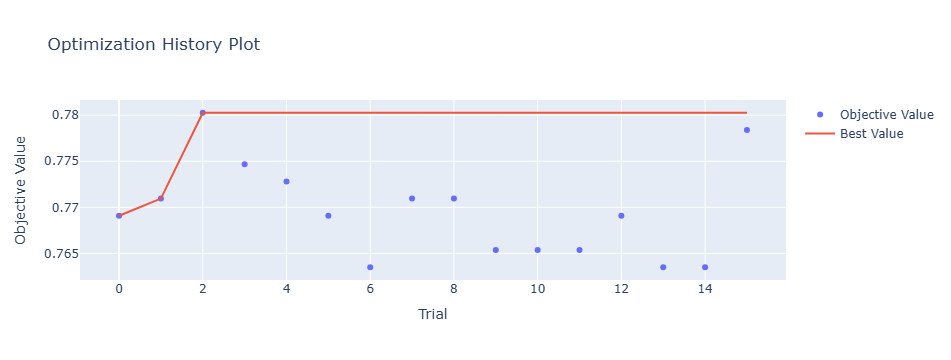

In [11]:
plot_optimization_history(study).show()

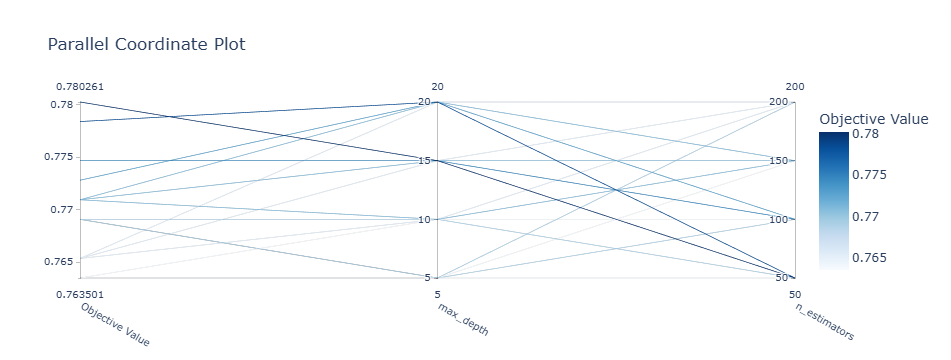

In [12]:
plot_parallel_coordinate(study).show()

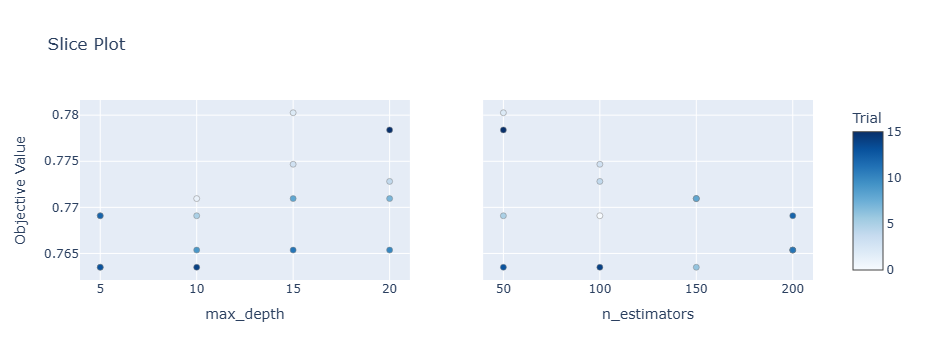

In [13]:
plot_slice(study).show()

In [14]:
plot_contour(study).show()

In [15]:
plot_param_importances(study).show()

In [20]:
# Define the objective function for Optuna
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [21]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2025-07-15 11:04:01,132] A new study created in memory with name: no-name-ad32474c-0774-4983-9ca3-f91724526ccd
[I 2025-07-15 11:04:02,850] Trial 0 finished with value: 0.7690875232774674 and parameters: {'classifier': 'RandomForest', 'n_estimators': 180, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 8, 'bootstrap': True}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-15 11:04:09,603] Trial 1 finished with value: 0.7486033519553074 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 258, 'learning_rate': 0.010153524584361263, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-15 11:04:16,775] Trial 2 finished with value: 0.7541899441340781 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 285, 'learning_rate': 0.014890487604424785, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-1

In [22]:
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'RandomForest', 'n_estimators': 93, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 2, 'bootstrap': False}
Best trial accuracy: 0.7951582867783985


In [23]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.769088,2025-07-15 11:04:01.134478,2025-07-15 11:04:02.850316,0 days 00:00:01.715838,NaN,True,RandomForest,NaN,NaN,NaN,18.0,8.0,9.0,180.0,COMPLETE
1,1,0.748603,2025-07-15 11:04:02.852439,2025-07-15 11:04:09.603347,0 days 00:00:06.750908,NaN,NaN,GradientBoosting,NaN,NaN,0.010154,6.0,1.0,5.0,258.0,COMPLETE
2,2,0.754190,2025-07-15 11:04:09.604939,2025-07-15 11:04:16.775225,0 days 00:00:07.170286,NaN,NaN,GradientBoosting,NaN,NaN,0.014890,6.0,3.0,8.0,285.0,COMPLETE
3,3,0.757914,2025-07-15 11:04:16.777056,2025-07-15 11:04:25.288921,0 days 00:00:08.511865,NaN,NaN,GradientBoosting,NaN,NaN,0.014564,11.0,7.0,4.0,284.0,COMPLETE
4,4,0.780261,2025-07-15 11:04:25.290269,2025-07-15 11:04:25.348044,0 days 00:00:00.057775,0.197554,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.778399,2025-07-15 11:06:24.783109,2025-07-15 11:06:25.614590,0 days 00:00:00.831481,NaN,False,RandomForest,NaN,NaN,NaN,12.0,2.0,8.0,76.0,COMPLETE
96,96,0.795158,2025-07-15 11:06:25.616339,2025-07-15 11:06:26.767912,0 days 00:00:01.151573,NaN,False,RandomForest,NaN,NaN,NaN,10.0,2.0,7.0,93.0,COMPLETE
97,97,0.787709,2025-07-15 11:06:26.769732,2025-07-15 11:06:28.009448,0 days 00:00:01.239716,NaN,False,RandomForest,NaN,NaN,NaN,9.0,1.0,7.0,100.0,COMPLETE
98,98,0.770950,2025-07-15 11:06:28.011188,2025-07-15 11:06:30.883483,0 days 00:00:02.872295,NaN,True,RandomForest,NaN,NaN,NaN,8.0,1.0,7.0,222.0,COMPLETE
